### Clasificacion de flores usando tensorflow

Se debe declarar que este codigo desarrollado e implementado es a base de la pagina oficial de Tensorflo 
link de la fuente de informacion: https://www.tensorflow.org/tutorials/images/classification?hl=es-419

In [1]:
import matplotlib.pyplot as plt 
import numpy as np 
import PIL
import tensorflow as tf
import pathlib

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

I0000 00:00:1775093026.187948    4718 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775093029.187081    4718 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775093054.278390    4718 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
## descargando los archivos para la clasificacion de flores 
import pathlib
dataset_url = 'https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz'
data_dir = tf.keras.utils.get_file('flowers_photos',origin=dataset_url, untar=True, cache_dir='.', cache_subdir='data')
data_dir = pathlib.Path(data_dir)
data_dir = data_dir / 'flower_photos'

### Creando conjunto de datos 
En esta parte del codigo, implementaremos la division de los dos conjuntos, los datos de entrenamiento y los datos de prueba 

In [3]:
batch_size = 32
img_height = 180
img_width = 180

#datos de entrenamiento
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.


E0000 00:00:1775093099.963135    4718 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
vals_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [5]:
#mostrando los nombres de las clases 
class_names = train_ds.class_names
print(class_names)

['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


## Visualizacion de los datos 
En esta parte haremos una visualizacion del conjunto de datos de entrenamiento 

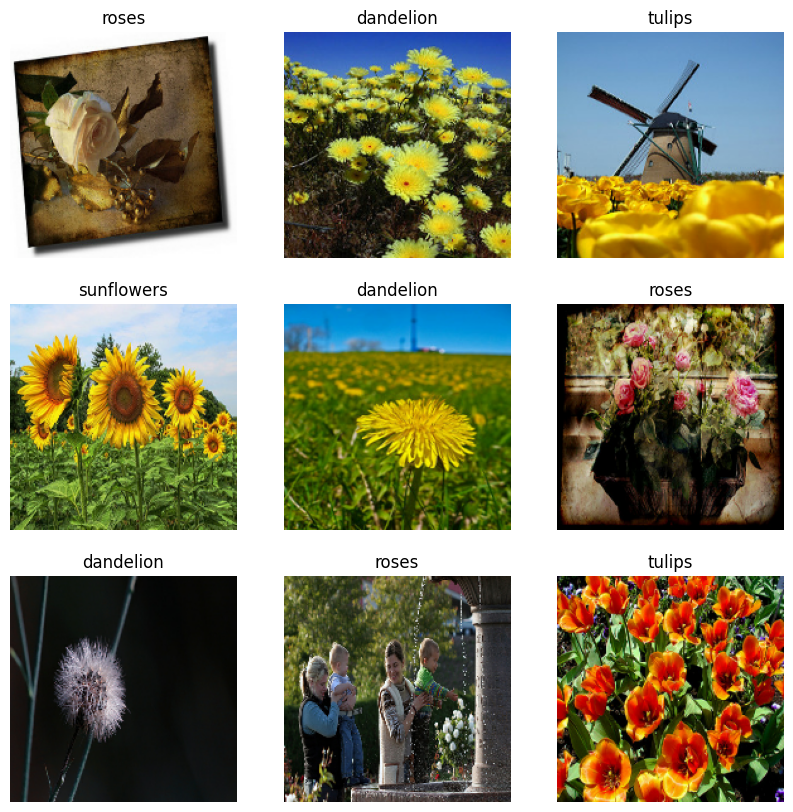

In [6]:
import matplotlib.pyplot as plt 

plt.figure(figsize=(10,10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis("off")

In [7]:
#configuracion para mejor rendimiento
autotune = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=autotune)
vals_ds = vals_ds.cache().prefetch(buffer_size=autotune)

In [8]:
#normalizando los datos para su entrada 
normalize_layer = layers.Rescaling(1./255)

normalize_ds = train_ds.map(lambda x, y: (normalize_layer(x),y))
image_batch, labels_batch = next(iter(normalize_ds))
first_image = image_batch[0]
print(np.min(first_image), np.max(first_image))

I0000 00:00:1775093125.830194    5975 shuffle_dataset_op.cc:453] ShuffleDatasetV3:16: Filling up shuffle buffer (this may take a while): 44 of 1000
I0000 00:00:1775093134.958718    5975 shuffle_dataset_op.cc:483] Shuffle buffer filled.


0.0 1.0


## creando el modelo 

In [9]:
num_classes = len(class_names)
#usando secuencial, en esta carpeta hay un codigo practica del uso de modelos secuencial 
model = Sequential([
    layers.Rescaling(1./255, input_shape=(img_height, img_width, 3)),
    layers.Conv2D(16,3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32,3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64,3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

/home/yuyots/Escritorio/PracticasIA/Clasificacionflores/.venv/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
#compilado el modelo usando la funcion adama 
model.compile(optimizer='adam',
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

#resumen del modelo 
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

### Proceso de entrenamiento del modelo

In [11]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=vals_ds,
    epochs=epochs
)

Epoch 1/10


92/92 ━━━━━━━━━━━━━━━━━━━━ 714s 8s/step - accuracy: 0.3774 - loss: 1.4429 - val_accuracy: 0.5150 - val_loss: 1.1890
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 415s 5s/step - accuracy: 0.5923 - loss: 1.0492 - val_accuracy: 0.5749 - val_loss: 1.0393
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 401s 4s/step - accuracy: 0.6529 - loss: 0.8871 - val_accuracy: 0.5995 - val_loss: 1.0304
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 374s 4s/step - accuracy: 0.7466 - loss: 0.6856 - val_accuracy: 0.6349 - val_loss: 0.9456
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 380s 4s/step - accuracy: 0.8386 - loss: 0.4610 - val_accuracy: 0.5409 - val_loss: 1.3797
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 376s 4s/step - accuracy: 0.9016 - loss: 0.3031 - val_accuracy: 0.6117 - val_loss: 1.2183
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 371s 4s/step - accuracy: 0.9601 - loss: 0.1505 - val_accuracy: 0.6226 - val_loss: 1.4776
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 376s 4s/step - accuracy: 0.9779 - loss: 0.0931 - val_accuracy: 0.5817 - val_loss: 1.

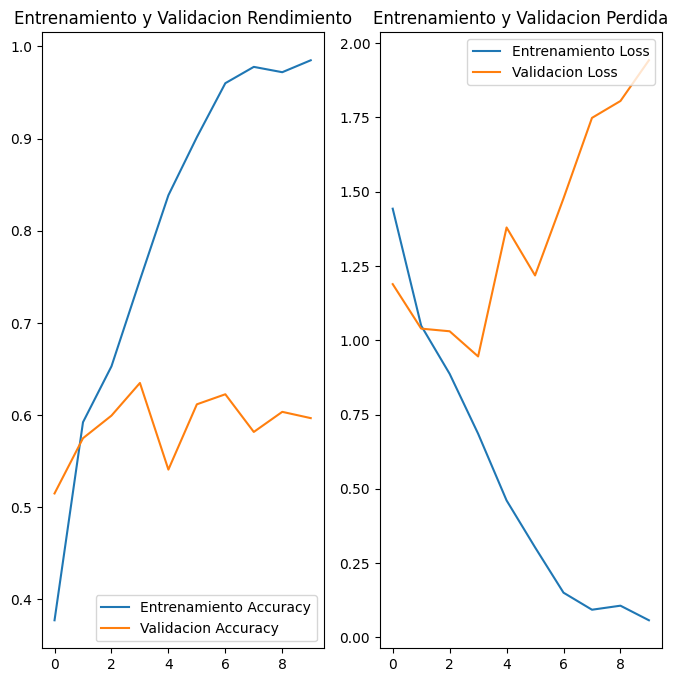

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento Accuracy')
plt.plot(epochs_range, val_acc, label='Validacion Accuracy')
plt.legend(loc='lower right')
plt.title('Entrenamiento y Validacion Rendimiento')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento Loss')
plt.plot(epochs_range, val_loss, label='Validacion Loss')
plt.legend(loc='upper right')
plt.title('Entrenamiento y Validacion Perdida')
plt.show()


### Aumento de datos

/home/yuyots/Escritorio/PracticasIA/Clasificacionflores/.venv/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


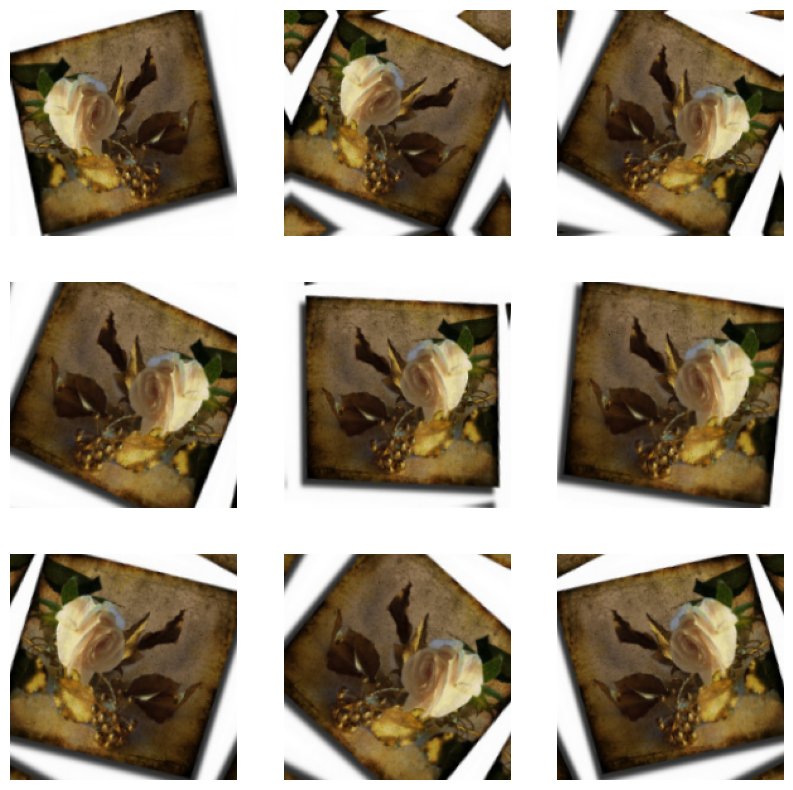

In [16]:
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal",
                          input_shape = (
                              img_height,
                              img_width,
                              3)),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)
#visualizacion de los ejemplos aumentados para solucionar el sobreajuste
plt.figure(figsize=(10,10))
for image, _ in train_ds.take(1):
    for i in range(9):
        augmented_images = data_augmentation(images)
        ax = plt.subplot(3,3, i+1)
        plt.imshow(augmented_images[0].numpy().astype("uint8"))
        plt.axis("off")

### Abandono 
Proceso o alternativa para tratar el sobre ajuste en la red neuronal 


In [17]:
model = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

In [18]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [19]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_2 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 180, 180, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 90, 90, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 90, 90, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 45, 45, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,965,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,989,285 (15.22 MB)

 Trainable params: 3,989,285 (15.22 MB)

 Non-trainable params: 0 (0.00 B)

In [20]:
epochs = 15
history = model.fit(
  train_ds,
  validation_data=vals_ds,
  epochs=epochs
)


Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 670s 7s/step - accuracy: 0.4322 - loss: 1.3190 - val_accuracy: 0.5845 - val_loss: 1.0732
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 613s 7s/step - accuracy: 0.5906 - loss: 1.0306 - val_accuracy: 0.6213 - val_loss: 0.9687
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 612s 7s/step - accuracy: 0.6304 - loss: 0.9315 - val_accuracy: 0.6431 - val_loss: 0.9003
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 620s 7s/step - accuracy: 0.6601 - loss: 0.8665 - val_accuracy: 0.6512 - val_loss: 0.8583
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 596s 6s/step - accuracy: 0.6812 - loss: 0.8050 - val_accuracy: 0.6798 - val_loss: 0.8678
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 616s 7s/step - accuracy: 0.7112 - loss: 0.7574 - val_accuracy: 0.7044 - val_loss: 0.7460
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 625s 7s/step - accuracy: 0.7210 - loss: 0.7215 - val_accuracy: 0.7112 - val_loss: 0.7352
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 623s 7s/step - accuracy: 0.7285 - loss: 0.7042 - val_accuracy: 0.7166 - v

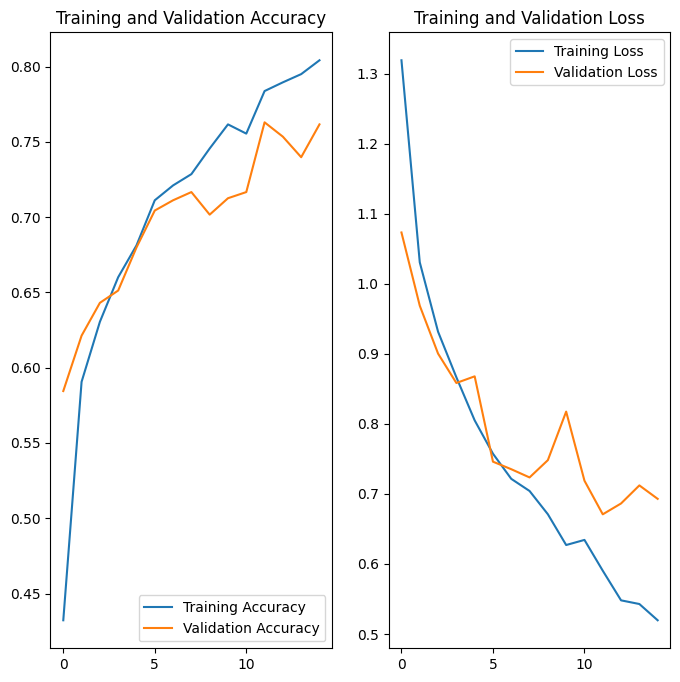

In [21]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [ ]:
sunflower_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/592px-Red_sunflower.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url)

img = tf.keras.utils.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

117948/117948 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
This image most likely belongs to sunflowers with a 99.58 percent confidence.
